Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
First 5 rows:
   id    age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  \
0   0  18393       2     168    62.0    110     80            1     1      0   
1   1  20228       1     156    85.0    140     90            3     1      0   
2   2  18857       1     165    64.0    130     70            3     1      0   
3   3  17623       2     169    82.0    150    100            1     1      0   
4   4  17474       1     156    56.0    100     60            1     1      0   

   alco  active  cardio  
0     0       1       0  
1     0       1       1  
2     0       0       1  
3     0       1       1  
4     0       0       0  

Dataset shape: (70000, 13)

Missing values:
id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco 

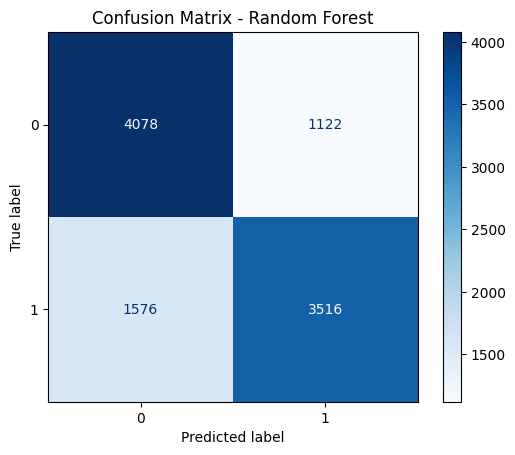

Confusion matrix saved to: /content/drive/MyDrive/ML_Assignment/RandomForest_Results_2/confusion_matrix.png

Feature Importance:
        Feature  Importance
4         ap_hi    0.376659
0           age    0.185470
5         ap_lo    0.158487
3        weight    0.090877
6   cholesterol    0.076391
2        height    0.064747
7          gluc    0.016096
10       active    0.011097
1        gender    0.009216
8         smoke    0.006227
9          alco    0.004733


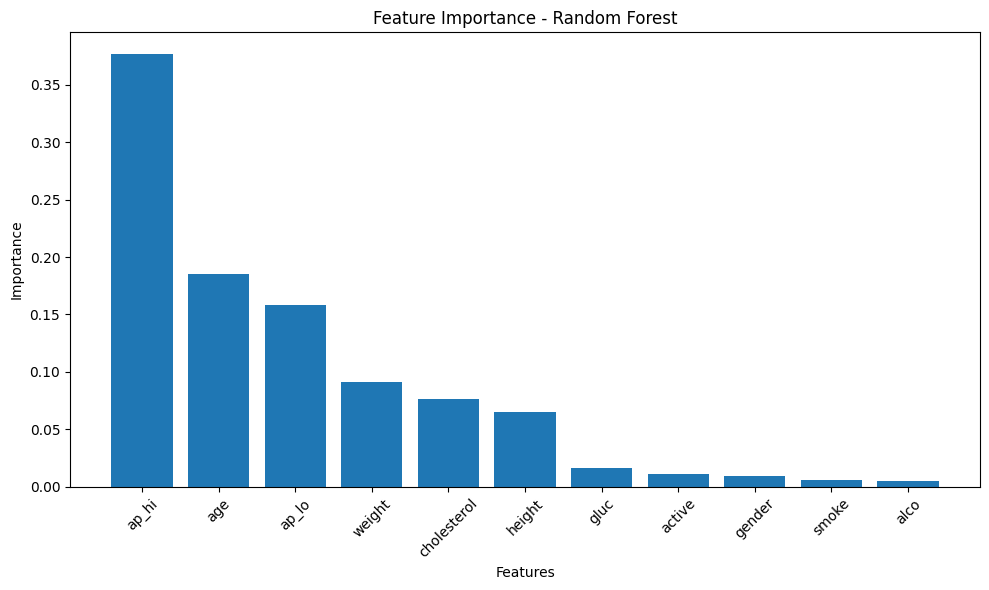

Feature importance CSV saved to: /content/drive/MyDrive/ML_Assignment/RandomForest_Results_2/feature_importance.csv
Feature importance plot saved to: /content/drive/MyDrive/ML_Assignment/RandomForest_Results_2/feature_importance.png


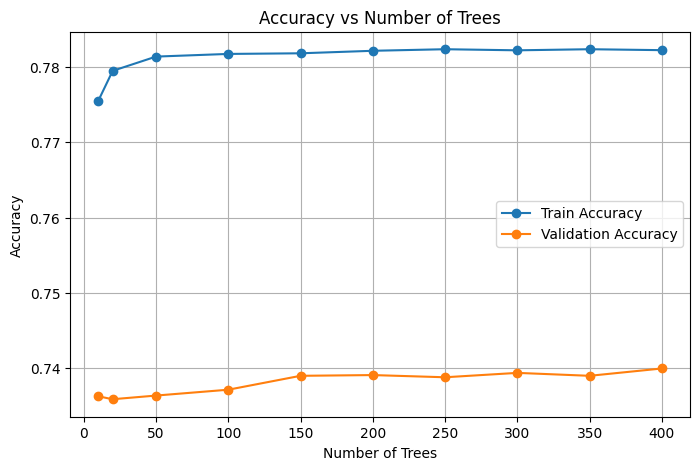

Accuracy curve saved to: /content/drive/MyDrive/ML_Assignment/RandomForest_Results_2/accuracy_curve.png


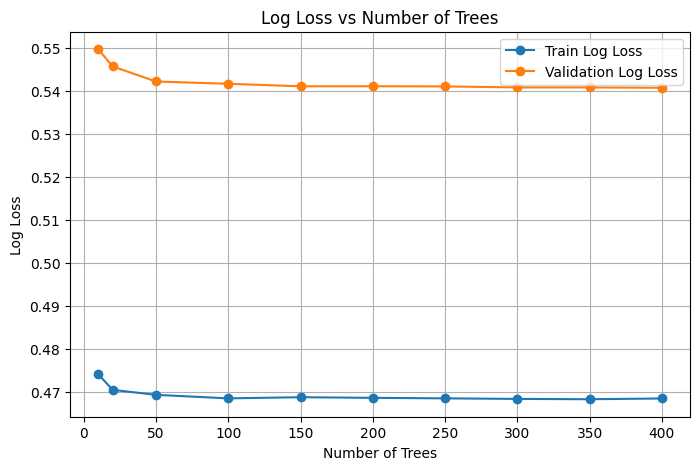

Loss curve saved to: /content/drive/MyDrive/ML_Assignment/RandomForest_Results_2/loss_curve.png


In [2]:
# ----------------------------
# 1. MOUNT GOOGLE DRIVE
# ----------------------------
from google.colab import drive
drive.mount('/content/drive')

# ----------------------------
# 2. IMPORT LIBRARIES
# ----------------------------
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    log_loss
)

# ----------------------------
# 3. PATHS
# ----------------------------
DATASET_PATH = "/content/drive/MyDrive/ML_Assignment/cardio_train.csv"
RESULTS_DIR = "/content/drive/MyDrive/ML_Assignment/RandomForest_Results_2"
os.makedirs(RESULTS_DIR, exist_ok=True)

# ----------------------------
# 4. LOAD DATASET
# ----------------------------
df = pd.read_csv(DATASET_PATH, sep=';')

print("First 5 rows:")
print(df.head())

print("\nDataset shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nClass distribution:")
print(df['cardio'].value_counts())

# ----------------------------
# 5. PREPROCESSING
# ----------------------------
# Drop duplicates
df = df.drop_duplicates()

# Drop id column
if 'id' in df.columns:
    df = df.drop('id', axis=1)

# Convert age from days to years
df['age'] = df['age'] / 365.25

# Remove unrealistic values
df = df[(df['ap_hi'] > 0) & (df['ap_lo'] > 0)]
df = df[(df['ap_hi'] > df['ap_lo'])]      # systolic should be greater than diastolic
df = df[(df['ap_hi'] >= 80) & (df['ap_hi'] <= 240)]
df = df[(df['ap_lo'] >= 40) & (df['ap_lo'] <= 160)]
df = df[(df['height'] >= 120) & (df['height'] <= 220)]
df = df[(df['weight'] >= 30) & (df['weight'] <= 200)]

print("\nShape after preprocessing:", df.shape)

# ----------------------------
# 6. FEATURES AND TARGET
# ----------------------------
X = df.drop('cardio', axis=1)
y = df['cardio']

# ----------------------------
# 7. TRAIN / VAL / TEST SPLIT
# ----------------------------
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("\nTrain shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

# ----------------------------
# 8. HYPERPARAMETER SEARCH
# ----------------------------
param_grid = {
    "n_estimators": [200, 300, 400],
    "max_depth": [10, 15, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

best_model = None
best_f1 = -1
best_params = None
results_list = []

print("\nSearching best parameters...\n")

for i, params in enumerate(ParameterGrid(param_grid), start=1):
    model = RandomForestClassifier(
        n_estimators=params["n_estimators"],
        max_depth=params["max_depth"],
        min_samples_split=params["min_samples_split"],
        min_samples_leaf=params["min_samples_leaf"],
        max_features=params["max_features"],
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)
    y_val_pred = model.predict(X_val)

    val_acc = accuracy_score(y_val, y_val_pred)
    val_prec = precision_score(y_val, y_val_pred)
    val_rec = recall_score(y_val, y_val_pred)
    val_f1 = f1_score(y_val, y_val_pred)

    results_list.append({
        **params,
        "val_accuracy": val_acc,
        "val_precision": val_prec,
        "val_recall": val_rec,
        "val_f1": val_f1
    })

    print(f"Model {i}: {params} --> Val F1 = {val_f1:.4f}")

    if val_f1 > best_f1:
        best_f1 = val_f1
        best_model = model
        best_params = params

print("\nBest Parameters:")
print(best_params)
print(f"Best Validation F1-score: {best_f1:.4f}")

# Save tuning results
tuning_df = pd.DataFrame(results_list)
tuning_csv = os.path.join(RESULTS_DIR, "hyperparameter_results.csv")
tuning_df.to_csv(tuning_csv, index=False)
print(f"\nHyperparameter search results saved to: {tuning_csv}")

# ----------------------------
# 9. SAVE BEST MODEL
# ----------------------------
best_model_path = os.path.join(RESULTS_DIR, "best_random_forest_model.pkl")
joblib.dump(best_model, best_model_path)
print(f"Best model saved to: {best_model_path}")

# ----------------------------
# 10. TEST SET EVALUATION
# ----------------------------
y_test_pred = best_model.predict(X_test)
y_test_proba = best_model.predict_proba(X_test)

accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)
test_loss = log_loss(y_test, y_test_proba)

print("\n===== TEST RESULTS =====")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")
print(f"Log Loss  : {test_loss:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

# Save metrics
metrics_path = os.path.join(RESULTS_DIR, "test_metrics.txt")
with open(metrics_path, "w") as f:
    f.write("===== TEST RESULTS =====\n")
    f.write(f"Best Parameters: {best_params}\n")
    f.write(f"Best Validation F1-score: {best_f1:.4f}\n")
    f.write(f"Accuracy  : {accuracy:.4f}\n")
    f.write(f"Precision : {precision:.4f}\n")
    f.write(f"Recall    : {recall:.4f}\n")
    f.write(f"F1-score  : {f1:.4f}\n")
    f.write(f"Log Loss  : {test_loss:.4f}\n\n")
    f.write("Classification Report:\n")
    f.write(classification_report(y_test, y_test_pred))

print(f"Metrics saved to: {metrics_path}")

# ----------------------------
# 11. CONFUSION MATRIX
# ----------------------------
cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
cm_path = os.path.join(RESULTS_DIR, "confusion_matrix.png")
plt.savefig(cm_path, bbox_inches='tight')
plt.show()

print(f"Confusion matrix saved to: {cm_path}")

# ----------------------------
# 12. FEATURE IMPORTANCE
# ----------------------------
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importance:")
print(feature_importance)

fi_csv_path = os.path.join(RESULTS_DIR, "feature_importance.csv")
feature_importance.to_csv(fi_csv_path, index=False)

plt.figure(figsize=(10, 6))
plt.bar(feature_importance['Feature'], feature_importance['Importance'])
plt.xticks(rotation=45)
plt.title("Feature Importance - Random Forest")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.tight_layout()
fi_plot_path = os.path.join(RESULTS_DIR, "feature_importance.png")
plt.savefig(fi_plot_path, bbox_inches='tight')
plt.show()

print(f"Feature importance CSV saved to: {fi_csv_path}")
print(f"Feature importance plot saved to: {fi_plot_path}")

# ----------------------------
# 13. ACCURACY AND LOSS CURVES
# Random Forest has no epoch-based loss,
# so we plot performance against number of trees
# ----------------------------
tree_values = [10, 20, 50, 100, 150, 200, 250, 300, 350, 400]

train_accs = []
val_accs = []
train_losses = []
val_losses = []

for n_trees in tree_values:
    temp_model = RandomForestClassifier(
        n_estimators=n_trees,
        max_depth=best_params["max_depth"],
        min_samples_split=best_params["min_samples_split"],
        min_samples_leaf=best_params["min_samples_leaf"],
        max_features=best_params["max_features"],
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    temp_model.fit(X_train, y_train)

    # Predictions
    y_train_pred = temp_model.predict(X_train)
    y_val_pred = temp_model.predict(X_val)

    y_train_proba = temp_model.predict_proba(X_train)
    y_val_proba = temp_model.predict_proba(X_val)

    # Accuracy
    train_accs.append(accuracy_score(y_train, y_train_pred))
    val_accs.append(accuracy_score(y_val, y_val_pred))

    # Log loss
    train_losses.append(log_loss(y_train, y_train_proba))
    val_losses.append(log_loss(y_val, y_val_proba))

# Accuracy graph
plt.figure(figsize=(8, 5))
plt.plot(tree_values, train_accs, marker='o', label='Train Accuracy')
plt.plot(tree_values, val_accs, marker='o', label='Validation Accuracy')
plt.title("Accuracy vs Number of Trees")
plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
acc_curve_path = os.path.join(RESULTS_DIR, "accuracy_curve.png")
plt.savefig(acc_curve_path, bbox_inches='tight')
plt.show()

print(f"Accuracy curve saved to: {acc_curve_path}")

# Loss graph
plt.figure(figsize=(8, 5))
plt.plot(tree_values, train_losses, marker='o', label='Train Log Loss')
plt.plot(tree_values, val_losses, marker='o', label='Validation Log Loss')
plt.title("Log Loss vs Number of Trees")
plt.xlabel("Number of Trees")
plt.ylabel("Log Loss")
plt.legend()
plt.grid(True)
loss_curve_path = os.path.join(RESULTS_DIR, "loss_curve.png")
plt.savefig(loss_curve_path, bbox_inches='tight')
plt.show()

print(f"Loss curve saved to: {loss_curve_path}")